In [1]:
# ============================================================
# MODEL 2B - BRAIN TUMOR CLASSIFICATION
# STEP 1: ENVIRONMENT SETUP
# ============================================================

import sys
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import torch
import torchvision

from PIL import Image

print("=" * 60)
print("MODEL 2B - ENVIRONMENT SETUP")
print("=" * 60)

print("Python version      :", sys.version)
print("PyTorch version     :", torch.__version__)
print("Torchvision version :", torchvision.__version__)

print("\nGPU available       :", torch.cuda.is_available())

if torch.cuda.is_available():

    print("GPU                 :",
          torch.cuda.get_device_name(0))

    print("CUDA version        :",
          torch.version.cuda)

    device = torch.device("cuda")

else:

    print("GPU                 : Not available")

    device = torch.device("cpu")

print("\nUsing device        :", device)

print("=" * 60)

MODEL 2B - ENVIRONMENT SETUP
Python version      : 3.12.13 (main, Mar  4 2026, 09:23:07) [GCC 11.4.0]
PyTorch version     : 2.11.0+cu128
Torchvision version : 0.26.0+cu128

GPU available       : True
GPU                 : Tesla T4
CUDA version        : 12.8

Using device        : cuda


In [2]:
# ============================================================
# MODEL 2B - STEP 2
# VERIFY KAGGLE CLI
# ============================================================

import subprocess
import sys

print("=" * 60)
print("MODEL 2B - KAGGLE VERIFICATION")
print("=" * 60)

try:

    result = subprocess.run(
        ["kaggle", "--version"],
        capture_output=True,
        text=True
    )

    print("\nKaggle version:")
    print(result.stdout)

    if result.returncode == 0:
        print("✅ Kaggle CLI is available")
    else:
        print("⚠️ Kaggle CLI returned an error")
        print(result.stderr)

except FileNotFoundError:

    print("❌ Kaggle CLI is not installed")
    print("\nInstall it using:")
    print("!pip install -q kaggle")

MODEL 2B - KAGGLE VERIFICATION

Kaggle version:
Kaggle CLI 2.0.2

✅ Kaggle CLI is available


In [3]:
# ============================================================
# MODEL 2B - STEP 3
# SEARCH FOR CT DATASET ON KAGGLE
# ============================================================

import subprocess

print("=" * 70)
print("MODEL 2B - KAGGLE CT DATASET SEARCH")
print("=" * 70)

result = subprocess.run(
    [
        "kaggle",
        "datasets",
        "list",
        "-s",
        "brain tumor multimodal CT MRI"
    ],
    capture_output=True,
    text=True
)

print(result.stdout)

if result.stderr:
    print("\nWarnings / Errors:")
    print(result.stderr)

MODEL 2B - KAGGLE CT DATASET SEARCH
You must authenticate before you can call the Kaggle API.
Follow the instructions to authenticate at: https://github.com/Kaggle/kaggle-cli/blob/main/docs/README.md#authentication



In [4]:
# ============================================================
# MODEL 2B - STEP 3A
# KAGGLE AUTHENTICATION
# ============================================================

!pip install -q -U kaggle

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 126.2/126.2 kB 10.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 262.5/262.5 kB 26.1 MB/s eta 0:00:00


In [5]:
# Check Kaggle version
!kaggle --version

Kaggle CLI 2.2.4


In [6]:
from google.colab import files

print("Upload your kaggle.json file")
uploaded = files.upload()

Upload your kaggle.json file


Saving kaggle.json to kaggle.json


In [7]:
# ============================================================
# CONFIGURE KAGGLE CREDENTIALS
# ============================================================

import os
import shutil

os.makedirs(
    "/root/.config/kaggle",
    exist_ok=True
)

shutil.move(
    "kaggle.json",
    "/root/.config/kaggle/kaggle.json"
)

os.chmod(
    "/root/.config/kaggle/kaggle.json",
    0o600
)

print("✅ Kaggle credentials configured")

✅ Kaggle credentials configured


In [8]:
# ============================================================
# VERIFY KAGGLE AUTHENTICATION
# ============================================================

!kaggle datasets list -s "brain tumor multimodal CT MRI"

ref                                                           title                                                    size  lastUpdated                 downloadCount  voteCount  usabilityRating  
------------------------------------------------------------  -------------------------------------------------  ----------  --------------------------  -------------  ---------  ---------------  
murtozalikhon/brain-tumor-multimodal-image-ct-and-mri         Brain tumor multimodal image (CT & MRI)             378311120  2024-12-03 12:48:16.463000           7554         80                1  
muhammethekimayvaz/clean-hybrid-brain-mri-dataset             Clean Hybrid Brain MRI Dataset                       77240730  2026-05-02 17:47:34.787000             13          9            0.875  
mohamedaymanhassan/brain-tumor-images-classification-by-cnn   Brain Tumor images Classification by CNN            378330360  2026-05-09 06:18:23.630000             13          0           0.5625  
ranitroy2005/br

In [9]:
# ============================================================
# MODEL 2B - STEP 4
# DOWNLOAD CT/MRI DATASET
# ============================================================

import os
import subprocess

DATASET_ID = "murtozalikhon/brain-tumor-multimodal-image-ct-and-mri"

ZIP_PATH = "/content/brain-tumor-multimodal-image-ct-and-mri.zip"

print("=" * 70)
print("MODEL 2B - DATASET DOWNLOAD")
print("=" * 70)

result = subprocess.run(
    [
        "kaggle",
        "datasets",
        "download",
        "-d",
        DATASET_ID,
        "-p",
        "/content"
    ],
    capture_output=True,
    text=True
)

print(result.stdout)

if result.returncode != 0:
    print("\n❌ Download failed")
    print(result.stderr)
else:
    print("\n✅ Dataset download command completed")

# ------------------------------------------------------------
# Verify downloaded ZIP
# ------------------------------------------------------------

if os.path.exists(ZIP_PATH):

    size_mb = (
        os.path.getsize(ZIP_PATH)
        / (1024 * 1024)
    )

    print("\n" + "=" * 70)
    print("DOWNLOAD VERIFICATION")
    print("=" * 70)

    print("Path :", ZIP_PATH)
    print(f"Size : {size_mb:.2f} MB")

else:

    print("\n⚠️ ZIP file was not found at expected path.")
    print("\nFiles currently in /content:")

    for item in os.listdir("/content"):
        print(" -", item)

MODEL 2B - DATASET DOWNLOAD
Dataset URL: https://www.kaggle.com/datasets/murtozalikhon/brain-tumor-multimodal-image-ct-and-mri
License(s): CC-BY-NC-SA-4.0



✅ Dataset download command completed

DOWNLOAD VERIFICATION
Path : /content/brain-tumor-multimodal-image-ct-and-mri.zip
Size : 360.79 MB


In [10]:
# ============================================================
# MODEL 2B - STEP 5
# EXTRACT DATASET
# ============================================================

import os
import zipfile

ZIP_PATH = "/content/brain-tumor-multimodal-image-ct-and-mri.zip"
EXTRACT_DIR = "/content/brain_dataset"

print("=" * 70)
print("MODEL 2B - DATASET EXTRACTION")
print("=" * 70)

# ------------------------------------------------------------
# Check ZIP
# ------------------------------------------------------------

if not os.path.exists(ZIP_PATH):
    raise FileNotFoundError(
        f"Dataset ZIP not found:\n{ZIP_PATH}"
    )

print("\nZIP file found:")
print(ZIP_PATH)


# ------------------------------------------------------------
# Extract
# ------------------------------------------------------------

if not os.path.exists(EXTRACT_DIR):

    print("\nExtracting dataset...")

    with zipfile.ZipFile(
        ZIP_PATH,
        "r"
    ) as zip_ref:

        zip_ref.extractall(
            EXTRACT_DIR
        )

    print("✅ Extraction completed")

else:

    print(
        "\n⚠️ Extraction directory already exists."
    )

    print(
        "Skipping extraction to avoid duplicate files."
    )


# ------------------------------------------------------------
# Display top-level structure
# ------------------------------------------------------------

print("\n" + "=" * 70)
print("EXTRACTED DATASET STRUCTURE")
print("=" * 70)

for root, dirs, files in os.walk(EXTRACT_DIR):

    level = root.replace(
        EXTRACT_DIR,
        ""
    ).count(os.sep)

    # Don't print too deeply
    if level > 4:
        continue

    indent = "    " * level

    print(
        f"{indent}{os.path.basename(root)}/"
    )

    if level <= 3:

        for filename in files[:5]:

            print(
                f"{indent}    {filename}"
            )

        if len(files) > 5:

            print(
                f"{indent}    ... "
                f"({len(files)} files)"
            )

MODEL 2B - DATASET EXTRACTION

ZIP file found:
/content/brain-tumor-multimodal-image-ct-and-mri.zip

Extracting dataset...
✅ Extraction completed

EXTRACTED DATASET STRUCTURE
brain_dataset/
    Dataset/
        Brain Tumor CT scan Images/
            CT image source.txt
            Healthy/
                ct_healthy (52).jpg
                ct_healthy (182).jpg
                ct_healthy (244).png
                ct_healthy (543).png
                ct_healthy (1154).jpg
                ... (2300 files)
            Tumor/
                ct_tumor (206).jpg
                ct_tumor (2040).jpg
                ct_tumor (1970).jpg
                ct_tumor (1039).jpg
                ct_tumor (1915).jpg
                ... (2318 files)
        Brain Tumor MRI images/
            MRI image source.txt
            Healthy/
                mri_healthy (1383).jpg
                mri_healthy (90).jpg
                mri_healthy (1880).jpg
                mri_healthy (89).jpg
                mri_h

In [11]:
# ============================================================
# MODEL 2B - CT TUMOR DETECTION
# STEP 6: VERIFY CT DATASET
# ============================================================

import os

CT_DIR = "/content/brain_dataset/Dataset/Brain Tumor CT scan Images"

HEALTHY_DIR = os.path.join(
    CT_DIR,
    "Healthy"
)

TUMOR_DIR = os.path.join(
    CT_DIR,
    "Tumor"
)

VALID_EXTENSIONS = (
    ".jpg",
    ".jpeg",
    ".png",
    ".bmp",
    ".webp"
)


def get_image_files(folder):

    return [
        os.path.join(folder, filename)
        for filename in os.listdir(folder)
        if (
            os.path.isfile(
                os.path.join(folder, filename)
            )
            and filename.lower().endswith(
                VALID_EXTENSIONS
            )
        )
    ]


healthy_images = get_image_files(
    HEALTHY_DIR
)

tumor_images = get_image_files(
    TUMOR_DIR
)


healthy_count = len(healthy_images)
tumor_count = len(tumor_images)
total_count = healthy_count + tumor_count


print("=" * 70)
print("MODEL 2B - CT DATASET VERIFICATION")
print("=" * 70)

print("\nCT Healthy images :", healthy_count)
print("CT Tumor images   :", tumor_count)
print("Total CT images   :", total_count)

print("\nExpected:")
print("CT Healthy : 2300")
print("CT Tumor   : 2318")
print("Total CT   : 4618")

print("\n" + "=" * 70)

if (
    healthy_count == 2300
    and tumor_count == 2318
):

    print("✅ CT DATASET VERIFIED SUCCESSFULLY")

else:

    print("⚠️ CT COUNTS DO NOT MATCH EXPECTED VALUES")

print("=" * 70)

MODEL 2B - CT DATASET VERIFICATION

CT Healthy images : 2300
CT Tumor images   : 2318
Total CT images   : 4618

Expected:
CT Healthy : 2300
CT Tumor   : 2318
Total CT   : 4618

✅ CT DATASET VERIFIED SUCCESSFULLY


MODEL 2B - CT IMAGE INSPECTION

CT HEALTHY
----------------------------------------
Filename : ct_healthy (52).jpg
Path     : /content/brain_dataset/Dataset/Brain Tumor CT scan Images/Healthy/ct_healthy (52).jpg
Format   : JPEG
Size     : (512, 512)
Mode     : RGB

CT TUMOR
----------------------------------------
Filename : ct_tumor (206).jpg
Path     : /content/brain_dataset/Dataset/Brain Tumor CT scan Images/Tumor/ct_tumor (206).jpg
Format   : JPEG
Size     : (640, 640)
Mode     : RGB


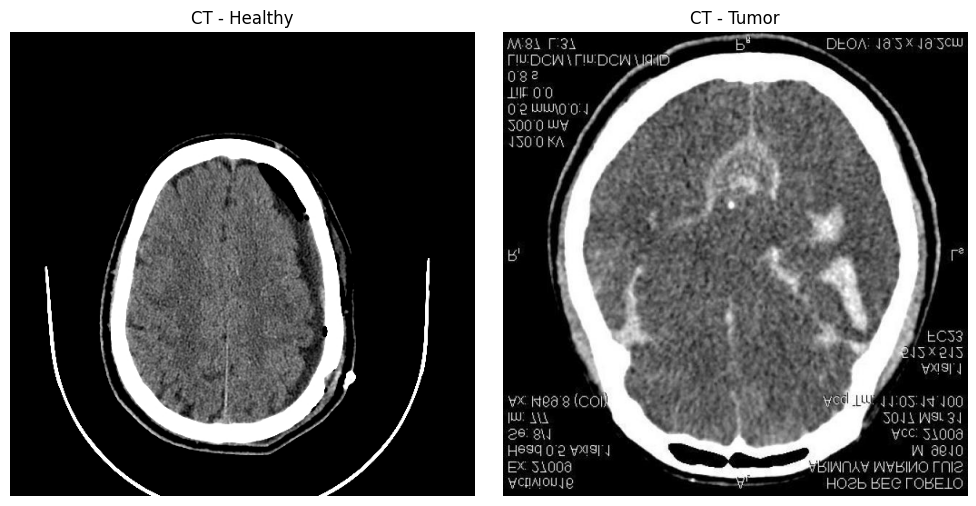

In [12]:
# ============================================================
# MODEL 2B - CT TUMOR DETECTION
# STEP 7: INSPECT CT IMAGES
# ============================================================

from PIL import Image
import os

# ------------------------------------------------------------
# Paths
# ------------------------------------------------------------

CT_DIR = "/content/brain_dataset/Dataset/Brain Tumor CT scan Images"

HEALTHY_DIR = os.path.join(
    CT_DIR,
    "Healthy"
)

TUMOR_DIR = os.path.join(
    CT_DIR,
    "Tumor"
)


# ------------------------------------------------------------
# Get image files
# ------------------------------------------------------------

VALID_EXTENSIONS = (
    ".jpg",
    ".jpeg",
    ".png",
    ".bmp",
    ".webp"
)

healthy_files = [
    f for f in os.listdir(HEALTHY_DIR)
    if f.lower().endswith(VALID_EXTENSIONS)
]

tumor_files = [
    f for f in os.listdir(TUMOR_DIR)
    if f.lower().endswith(VALID_EXTENSIONS)
]


# ------------------------------------------------------------
# Select sample images
# ------------------------------------------------------------

healthy_path = os.path.join(
    HEALTHY_DIR,
    healthy_files[0]
)

tumor_path = os.path.join(
    TUMOR_DIR,
    tumor_files[0]
)


# ------------------------------------------------------------
# Open images
# ------------------------------------------------------------

healthy_image = Image.open(
    healthy_path
)

tumor_image = Image.open(
    tumor_path
)


# ------------------------------------------------------------
# Display information
# ------------------------------------------------------------

print("=" * 70)
print("MODEL 2B - CT IMAGE INSPECTION")
print("=" * 70)

print("\nCT HEALTHY")
print("-" * 40)

print("Filename :", healthy_files[0])
print("Path     :", healthy_path)
print("Format   :", healthy_image.format)
print("Size     :", healthy_image.size)
print("Mode     :", healthy_image.mode)


print("\nCT TUMOR")
print("-" * 40)

print("Filename :", tumor_files[0])
print("Path     :", tumor_path)
print("Format   :", tumor_image.format)
print("Size     :", tumor_image.size)
print("Mode     :", tumor_image.mode)


# ------------------------------------------------------------
# Display images
# ------------------------------------------------------------

import matplotlib.pyplot as plt

plt.figure(figsize=(10, 5))


plt.subplot(1, 2, 1)

plt.imshow(
    healthy_image,
    cmap="gray"
)

plt.title("CT - Healthy")

plt.axis("off")


plt.subplot(1, 2, 2)

plt.imshow(
    tumor_image,
    cmap="gray"
)

plt.title("CT - Tumor")

plt.axis("off")


plt.tight_layout()

plt.show()

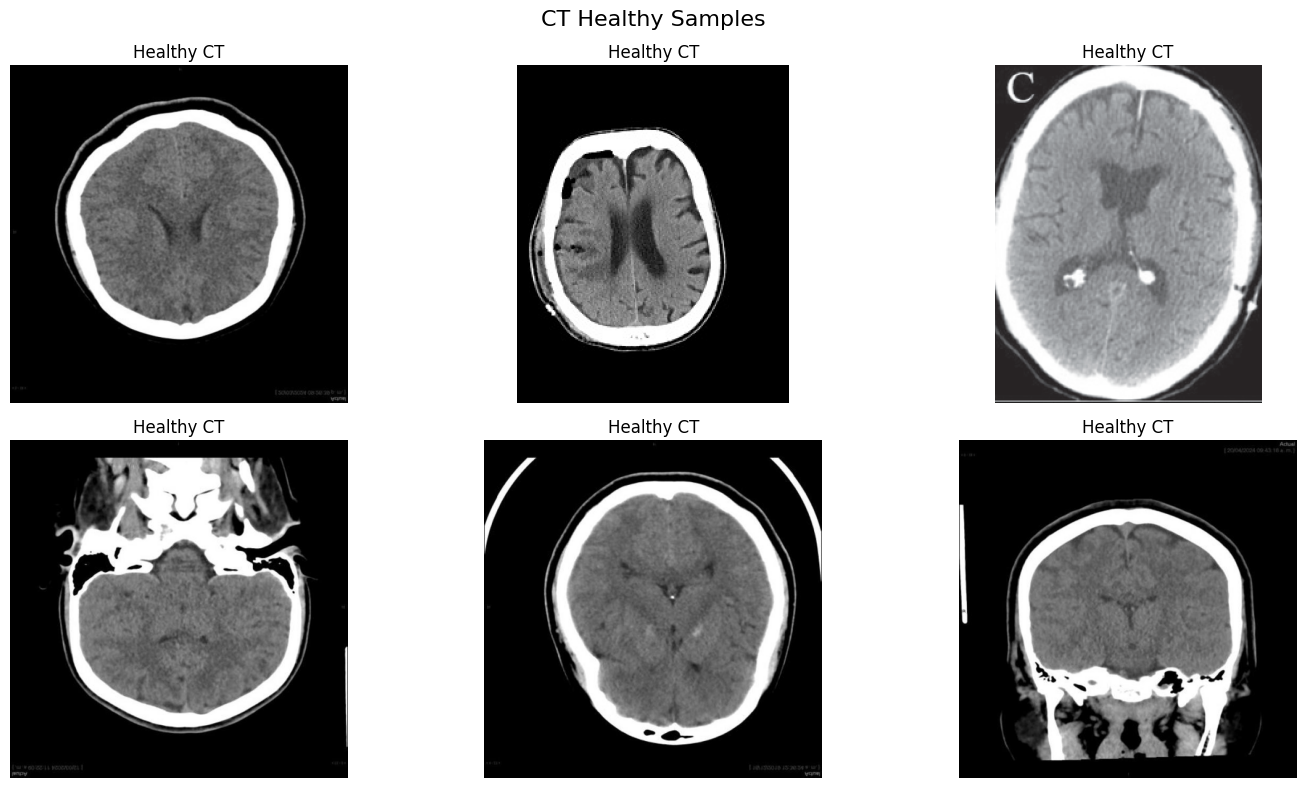

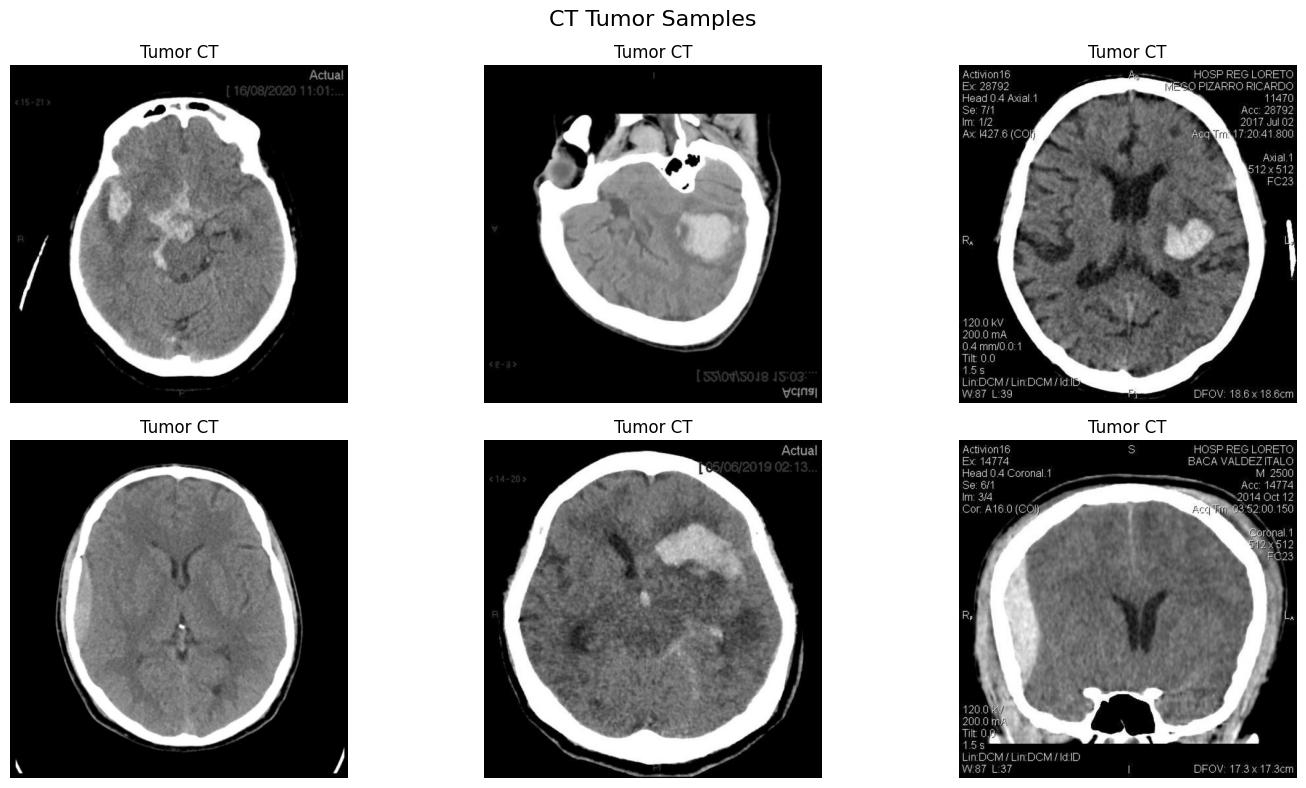

CT VISUAL INSPECTION COMPLETE

Healthy samples displayed : 6
Tumor samples displayed   : 6

✅ Visual inspection completed


In [13]:
# ============================================================
# MODEL 2B - CT TUMOR DETECTION
# STEP 8: VISUAL CT DATASET INSPECTION
# ============================================================

import os
import random
import matplotlib.pyplot as plt
from PIL import Image

# ------------------------------------------------------------
# Paths
# ------------------------------------------------------------

CT_DIR = "/content/brain_dataset/Dataset/Brain Tumor CT scan Images"

HEALTHY_DIR = os.path.join(
    CT_DIR,
    "Healthy"
)

TUMOR_DIR = os.path.join(
    CT_DIR,
    "Tumor"
)

VALID_EXTENSIONS = (
    ".jpg",
    ".jpeg",
    ".png",
    ".bmp",
    ".webp"
)


# ------------------------------------------------------------
# Get image paths
# ------------------------------------------------------------

healthy_files = [
    os.path.join(HEALTHY_DIR, f)
    for f in os.listdir(HEALTHY_DIR)
    if f.lower().endswith(VALID_EXTENSIONS)
]

tumor_files = [
    os.path.join(TUMOR_DIR, f)
    for f in os.listdir(TUMOR_DIR)
    if f.lower().endswith(VALID_EXTENSIONS)
]


# ------------------------------------------------------------
# Random samples
# ------------------------------------------------------------

random.seed(42)

healthy_samples = random.sample(
    healthy_files,
    6
)

tumor_samples = random.sample(
    tumor_files,
    6
)


# ============================================================
# HEALTHY CT SAMPLES
# ============================================================

plt.figure(figsize=(15, 8))

for i, image_path in enumerate(healthy_samples):

    image = Image.open(
        image_path
    ).convert("RGB")

    plt.subplot(2, 3, i + 1)

    plt.imshow(image)

    plt.title("Healthy CT")

    plt.axis("off")

plt.suptitle(
    "CT Healthy Samples",
    fontsize=16
)

plt.tight_layout()

plt.show()


# ============================================================
# TUMOR CT SAMPLES
# ============================================================

plt.figure(figsize=(15, 8))

for i, image_path in enumerate(tumor_samples):

    image = Image.open(
        image_path
    ).convert("RGB")

    plt.subplot(2, 3, i + 1)

    plt.imshow(image)

    plt.title("Tumor CT")

    plt.axis("off")

plt.suptitle(
    "CT Tumor Samples",
    fontsize=16
)

plt.tight_layout()

plt.show()


# ============================================================
# SUMMARY
# ============================================================

print("=" * 70)
print("CT VISUAL INSPECTION COMPLETE")
print("=" * 70)

print("\nHealthy samples displayed :", len(healthy_samples))
print("Tumor samples displayed   :", len(tumor_samples))

print("\n✅ Visual inspection completed")
print("=" * 70)

In [14]:
# ============================================================
# MODEL 2B - CT TUMOR DETECTION
# STEP 9: CREATE CT DATAFRAME
# ============================================================

import os
import pandas as pd

# ------------------------------------------------------------
# Dataset paths
# ------------------------------------------------------------

CT_DIR = "/content/brain_dataset/Dataset/Brain Tumor CT scan Images"

HEALTHY_DIR = os.path.join(
    CT_DIR,
    "Healthy"
)

TUMOR_DIR = os.path.join(
    CT_DIR,
    "Tumor"
)

VALID_EXTENSIONS = (
    ".jpg",
    ".jpeg",
    ".png",
    ".bmp",
    ".webp"
)


# ------------------------------------------------------------
# Create records
# ------------------------------------------------------------

data = []


# ------------------------------------------------------------
# Healthy CT → label 0
# ------------------------------------------------------------

for filename in os.listdir(HEALTHY_DIR):

    filepath = os.path.join(
        HEALTHY_DIR,
        filename
    )

    if (
        os.path.isfile(filepath)
        and filename.lower().endswith(
            VALID_EXTENSIONS
        )
    ):

        data.append({
            "filepath": filepath,
            "label": 0,
            "class_name": "Healthy"
        })


# ------------------------------------------------------------
# Tumor CT → label 1
# ------------------------------------------------------------

for filename in os.listdir(TUMOR_DIR):

    filepath = os.path.join(
        TUMOR_DIR,
        filename
    )

    if (
        os.path.isfile(filepath)
        and filename.lower().endswith(
            VALID_EXTENSIONS
        )
    ):

        data.append({
            "filepath": filepath,
            "label": 1,
            "class_name": "Tumor"
        })


# ------------------------------------------------------------
# Create DataFrame
# ------------------------------------------------------------

ct_df = pd.DataFrame(data)


# ------------------------------------------------------------
# Shuffle
# ------------------------------------------------------------

ct_df = ct_df.sample(
    frac=1,
    random_state=42
).reset_index(drop=True)


# ------------------------------------------------------------
# Display information
# ------------------------------------------------------------

print("=" * 70)
print("MODEL 2B - CT DATAFRAME")
print("=" * 70)

print("\nTotal CT images:", len(ct_df))

print("\nClass distribution:")
print(
    ct_df["class_name"].value_counts()
)

print("\nLabel distribution:")
print(
    ct_df["label"].value_counts()
)

print("\nDataFrame shape:")
print(
    ct_df.shape
)

print("\nFirst 10 rows:")
display(
    ct_df.head(10)
)

MODEL 2B - CT DATAFRAME

Total CT images: 4618

Class distribution:
class_name
Tumor      2318
Healthy    2300
Name: count, dtype: int64

Label distribution:
label
1    2318
0    2300
Name: count, dtype: int64

DataFrame shape:
(4618, 3)

First 10 rows:


,filepath,label,class_name
0,/content/brain_dataset/Dataset/Brain Tumor CT ...,1,Tumor
1,/content/brain_dataset/Dataset/Brain Tumor CT ...,1,Tumor
2,/content/brain_dataset/Dataset/Brain Tumor CT ...,1,Tumor
3,/content/brain_dataset/Dataset/Brain Tumor CT ...,0,Healthy
4,/content/brain_dataset/Dataset/Brain Tumor CT ...,0,Healthy
5,/content/brain_dataset/Dataset/Brain Tumor CT ...,0,Healthy
6,/content/brain_dataset/Dataset/Brain Tumor CT ...,0,Healthy
7,/content/brain_dataset/Dataset/Brain Tumor CT ...,0,Healthy
8,/content/brain_dataset/Dataset/Brain Tumor CT ...,1,Tumor
9,/content/brain_dataset/Dataset/Brain Tumor CT ...,1,Tumor


In [15]:
# ============================================================
# MODEL 2B - CT TUMOR DETECTION
# STEP 10: CT DATASET VALIDATION
# ============================================================

import os

print("=" * 70)
print("MODEL 2B - CT DATASET VALIDATION")
print("=" * 70)


# ------------------------------------------------------------
# 1. Basic counts
# ------------------------------------------------------------

print("\nTotal CT images:", len(ct_df))

print("\nClass distribution:")
print(ct_df["class_name"].value_counts())

print("\nLabel distribution:")
print(ct_df["label"].value_counts())


# ------------------------------------------------------------
# 2. Verify label mapping
# ------------------------------------------------------------

print("\n" + "=" * 70)
print("LABEL MAPPING")
print("=" * 70)

mapping = ct_df.groupby(
    ["class_name", "label"]
).size()

print(mapping)


# ------------------------------------------------------------
# 3. Check correct / incorrect labels
# ------------------------------------------------------------

healthy_correct = (
    (ct_df["class_name"] == "Healthy") &
    (ct_df["label"] == 0)
).sum()

healthy_wrong = (
    (ct_df["class_name"] == "Healthy") &
    (ct_df["label"] != 0)
).sum()

tumor_correct = (
    (ct_df["class_name"] == "Tumor") &
    (ct_df["label"] == 1)
).sum()

tumor_wrong = (
    (ct_df["class_name"] == "Tumor") &
    (ct_df["label"] != 1)
).sum()


print("\nHealthy correctly labeled  :", healthy_correct)
print("Healthy incorrectly labeled:", healthy_wrong)

print("\nTumor correctly labeled    :", tumor_correct)
print("Tumor incorrectly labeled  :", tumor_wrong)


# ------------------------------------------------------------
# 4. Check missing files
# ------------------------------------------------------------

missing_files = ct_df[
    ~ct_df["filepath"].apply(os.path.exists)
]

print("\n" + "=" * 70)
print("FILE EXISTENCE CHECK")
print("=" * 70)

print("Missing files:", len(missing_files))


# ------------------------------------------------------------
# 5. Check duplicate paths
# ------------------------------------------------------------

duplicate_paths = ct_df[
    ct_df["filepath"].duplicated()
]

print("Duplicate file paths:", len(duplicate_paths))


# ------------------------------------------------------------
# 6. Final validation
# ------------------------------------------------------------

print("\n" + "=" * 70)
print("FINAL VALIDATION")
print("=" * 70)

if (
    len(ct_df) == 4618
    and healthy_correct == 2300
    and tumor_correct == 2318
    and healthy_wrong == 0
    and tumor_wrong == 0
    and len(missing_files) == 0
    and len(duplicate_paths) == 0
):

    print("✅ CT DATASET VALIDATION PASSED")

else:

    print("⚠️ CT DATASET VALIDATION FAILED")

print("=" * 70)

MODEL 2B - CT DATASET VALIDATION

Total CT images: 4618

Class distribution:
class_name
Tumor      2318
Healthy    2300
Name: count, dtype: int64

Label distribution:
label
1    2318
0    2300
Name: count, dtype: int64

LABEL MAPPING
class_name  label
Healthy     0        2300
Tumor       1        2318
dtype: int64

Healthy correctly labeled  : 2300
Healthy incorrectly labeled: 0

Tumor correctly labeled    : 2318
Tumor incorrectly labeled  : 0

FILE EXISTENCE CHECK
Missing files: 0
Duplicate file paths: 0

FINAL VALIDATION
✅ CT DATASET VALIDATION PASSED


In [16]:
# ============================================================
# MODEL 2B - CT TUMOR DETECTION
# STEP 11: TRAIN / VALIDATION / TEST SPLIT
# ============================================================

from sklearn.model_selection import train_test_split

# ------------------------------------------------------------
# First split:
# 70% Train
# 30% Temporary
# ------------------------------------------------------------

train_ct_df, temp_ct_df = train_test_split(
    ct_df,
    test_size=0.30,
    stratify=ct_df["label"],
    random_state=42
)


# ------------------------------------------------------------
# Second split:
# Temporary → 50% Validation + 50% Test
#
# 30% × 50% = 15%
# ------------------------------------------------------------

val_ct_df, test_ct_df = train_test_split(
    temp_ct_df,
    test_size=0.50,
    stratify=temp_ct_df["label"],
    random_state=42
)


# ------------------------------------------------------------
# Reset indexes
# ------------------------------------------------------------

train_ct_df = train_ct_df.reset_index(drop=True)
val_ct_df = val_ct_df.reset_index(drop=True)
test_ct_df = test_ct_df.reset_index(drop=True)


# ------------------------------------------------------------
# Display sizes
# ------------------------------------------------------------

print("=" * 70)
print("MODEL 2B - CT DATASET SPLIT")
print("=" * 70)

print("\nDataset sizes:")

print("Training   :", len(train_ct_df))
print("Validation :", len(val_ct_df))
print("Testing    :", len(test_ct_df))

print(
    "Total      :",
    len(train_ct_df)
    + len(val_ct_df)
    + len(test_ct_df)
)


# ------------------------------------------------------------
# Training distribution
# ------------------------------------------------------------

print("\n" + "=" * 70)
print("TRAINING DISTRIBUTION")
print("=" * 70)

print(
    train_ct_df["class_name"].value_counts()
)


# ------------------------------------------------------------
# Validation distribution
# ------------------------------------------------------------

print("\n" + "=" * 70)
print("VALIDATION DISTRIBUTION")
print("=" * 70)

print(
    val_ct_df["class_name"].value_counts()
)


# ------------------------------------------------------------
# Test distribution
# ------------------------------------------------------------

print("\n" + "=" * 70)
print("TEST DISTRIBUTION")
print("=" * 70)

print(
    test_ct_df["class_name"].value_counts()
)

MODEL 2B - CT DATASET SPLIT

Dataset sizes:
Training   : 3232
Validation : 693
Testing    : 693
Total      : 4618

TRAINING DISTRIBUTION
class_name
Tumor      1622
Healthy    1610
Name: count, dtype: int64

VALIDATION DISTRIBUTION
class_name
Tumor      348
Healthy    345
Name: count, dtype: int64

TEST DISTRIBUTION
class_name
Tumor      348
Healthy    345
Name: count, dtype: int64


In [17]:
# ============================================================
# MODEL 2B - CT TUMOR DETECTION
# STEP 12: IMAGE PREPROCESSING & AUGMENTATION
# ============================================================

from torchvision import transforms

# ------------------------------------------------------------
# ImageNet normalization
# ------------------------------------------------------------

IMAGENET_MEAN = [
    0.485,
    0.456,
    0.406
]

IMAGENET_STD = [
    0.229,
    0.224,
    0.225
]


# ------------------------------------------------------------
# Training transformations
# ------------------------------------------------------------

train_ct_transform = transforms.Compose([

    # Ensure every CT image has 3 channels
    transforms.Lambda(
        lambda img: img.convert("RGB")
    ),

    # Standard input size
    transforms.Resize(
        (224, 224)
    ),

    # Moderate augmentation
    transforms.RandomHorizontalFlip(
        p=0.5
    ),

    transforms.RandomRotation(
        degrees=10
    ),

    transforms.ColorJitter(
        brightness=0.15,
        contrast=0.15
    ),

    # PIL → Tensor
    transforms.ToTensor(),

    # ImageNet normalization
    transforms.Normalize(
        mean=IMAGENET_MEAN,
        std=IMAGENET_STD
    )
])


# ------------------------------------------------------------
# Validation transformations
# ------------------------------------------------------------

val_ct_transform = transforms.Compose([

    transforms.Lambda(
        lambda img: img.convert("RGB")
    ),

    transforms.Resize(
        (224, 224)
    ),

    transforms.ToTensor(),

    transforms.Normalize(
        mean=IMAGENET_MEAN,
        std=IMAGENET_STD
    )
])


# ------------------------------------------------------------
# Test transformations
# ------------------------------------------------------------

test_ct_transform = transforms.Compose([

    transforms.Lambda(
        lambda img: img.convert("RGB")
    ),

    transforms.Resize(
        (224, 224)
    ),

    transforms.ToTensor(),

    transforms.Normalize(
        mean=IMAGENET_MEAN,
        std=IMAGENET_STD
    )
])


# ------------------------------------------------------------
# Display
# ------------------------------------------------------------

print("=" * 70)
print("MODEL 2B - CT IMAGE TRANSFORMS")
print("=" * 70)

print("\nTraining transformations:")
print(train_ct_transform)

print("\nValidation transformations:")
print(val_ct_transform)

print("\nTest transformations:")
print(test_ct_transform)

print("\nImage size : 224 × 224")
print("Channels   : 3 (RGB)")
print("Normalization: ImageNet")

print("\n✅ CT transforms configured successfully")
print("=" * 70)

MODEL 2B - CT IMAGE TRANSFORMS

Training transformations:
Compose(
    Lambda()
    Resize(size=(224, 224), interpolation=bilinear, max_size=None, antialias=True)
    RandomHorizontalFlip(p=0.5)
    RandomRotation(degrees=[-10.0, 10.0], interpolation=nearest, expand=False, fill=0)
    ColorJitter(brightness=(0.85, 1.15), contrast=(0.85, 1.15), saturation=None, hue=None)
    ToTensor()
    Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
)

Validation transformations:
Compose(
    Lambda()
    Resize(size=(224, 224), interpolation=bilinear, max_size=None, antialias=True)
    ToTensor()
    Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
)

Test transformations:
Compose(
    Lambda()
    Resize(size=(224, 224), interpolation=bilinear, max_size=None, antialias=True)
    ToTensor()
    Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
)

Image size : 224 × 224
Channels   : 3 (RGB)
Normalization: ImageNet

✅ CT transforms configured successful

In [18]:
# ============================================================
# MODEL 2B - CT TUMOR DETECTION
# STEP 13: PYTORCH CT DATASET
# ============================================================

import torch
from torch.utils.data import Dataset
from PIL import Image


class CTTumorDataset(Dataset):

    def __init__(self, dataframe, transform=None):

        self.dataframe = dataframe.reset_index(drop=True)
        self.transform = transform


    def __len__(self):

        return len(self.dataframe)


    def __getitem__(self, index):

        # ----------------------------------------------------
        # Get image path
        # ----------------------------------------------------

        image_path = self.dataframe.loc[
            index,
            "filepath"
        ]

        # ----------------------------------------------------
        # Get label
        # ----------------------------------------------------

        label = self.dataframe.loc[
            index,
            "label"
        ]

        # ----------------------------------------------------
        # Load CT image
        # ----------------------------------------------------

        image = Image.open(
            image_path
        ).convert("RGB")

        # ----------------------------------------------------
        # Apply transformation
        # ----------------------------------------------------

        if self.transform is not None:

            image = self.transform(
                image
            )

        # ----------------------------------------------------
        # Convert label to tensor
        # ----------------------------------------------------

        label = torch.tensor(
            label,
            dtype=torch.long
        )

        return image, label


# ============================================================
# CREATE DATASETS
# ============================================================

train_ct_dataset = CTTumorDataset(
    dataframe=train_ct_df,
    transform=train_ct_transform
)

val_ct_dataset = CTTumorDataset(
    dataframe=val_ct_df,
    transform=val_ct_transform
)

test_ct_dataset = CTTumorDataset(
    dataframe=test_ct_df,
    transform=test_ct_transform
)


# ============================================================
# VERIFY DATASET SIZES
# ============================================================

print("=" * 70)
print("MODEL 2B - PYTORCH CT DATASET")
print("=" * 70)

print("\nTraining dataset   :", len(train_ct_dataset))
print("Validation dataset :", len(val_ct_dataset))
print("Test dataset       :", len(test_ct_dataset))

print("\nExpected:")
print("Training   : 3232")
print("Validation : 693")
print("Test       : 693")

print("=" * 70)

MODEL 2B - PYTORCH CT DATASET

Training dataset   : 3232
Validation dataset : 693
Test dataset       : 693

Expected:
Training   : 3232
Validation : 693
Test       : 693


In [19]:
# ============================================================
# MODEL 2B - CT TUMOR DETECTION
# STEP 14: VERIFY TRANSFORMED CT SAMPLE
# ============================================================

import torch

print("=" * 70)
print("MODEL 2B - TRANSFORMED CT SAMPLE VERIFICATION")
print("=" * 70)

# Get one sample
image, label = train_ct_dataset[0]

print("\nImage information:")
print("Type  :", type(image))
print("Shape :", image.shape)
print("Dtype :", image.dtype)

print("\nLabel information:")
print("Type  :", type(label))
print("Value :", label.item())
print("Dtype :", label.dtype)


# ------------------------------------------------------------
# Verification
# ------------------------------------------------------------

print("\n" + "=" * 70)
print("VERIFICATION")
print("=" * 70)

if (
    isinstance(image, torch.Tensor)
    and image.shape == (3, 224, 224)
    and image.dtype == torch.float32
    and label.item() in [0, 1]
):

    print("✅ TRANSFORMED CT SAMPLE VERIFIED")

else:

    print("⚠️ SOMETHING IS INCORRECT")

print("=" * 70)

MODEL 2B - TRANSFORMED CT SAMPLE VERIFICATION

Image information:
Type  : <class 'torch.Tensor'>
Shape : torch.Size([3, 224, 224])
Dtype : torch.float32

Label information:
Type  : <class 'torch.Tensor'>
Value : 1
Dtype : torch.int64

VERIFICATION
✅ TRANSFORMED CT SAMPLE VERIFIED


In [20]:
# ============================================================
# MODEL 2B - CT TUMOR DETECTION
# STEP 15: CREATE CT DATALOADERS
# ============================================================

from torch.utils.data import DataLoader

# ------------------------------------------------------------
# Configuration
# ------------------------------------------------------------

BATCH_SIZE = 32
NUM_WORKERS = 2


# ------------------------------------------------------------
# Training DataLoader
# ------------------------------------------------------------

train_ct_loader = DataLoader(
    train_ct_dataset,
    batch_size=BATCH_SIZE,
    shuffle=True,
    num_workers=NUM_WORKERS,
    pin_memory=True
)


# ------------------------------------------------------------
# Validation DataLoader
# ------------------------------------------------------------

val_ct_loader = DataLoader(
    val_ct_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False,
    num_workers=NUM_WORKERS,
    pin_memory=True
)


# ------------------------------------------------------------
# Test DataLoader
# ------------------------------------------------------------

test_ct_loader = DataLoader(
    test_ct_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False,
    num_workers=NUM_WORKERS,
    pin_memory=True
)


# ------------------------------------------------------------
# Display
# ------------------------------------------------------------

print("=" * 70)
print("MODEL 2B - CT DATALOADERS")
print("=" * 70)

print("\nBatch size    :", BATCH_SIZE)
print("Num workers   :", NUM_WORKERS)

print("\nTraining batches   :", len(train_ct_loader))
print("Validation batches :", len(val_ct_loader))
print("Test batches       :", len(test_ct_loader))

print("=" * 70)

MODEL 2B - CT DATALOADERS

Batch size    : 32
Num workers   : 2

Training batches   : 101
Validation batches : 22
Test batches       : 22


In [21]:
# ============================================================
# MODEL 2B - CT TUMOR DETECTION
# STEP 16: VERIFY CT DATALOADER BATCH
# ============================================================

import torch

print("=" * 70)
print("MODEL 2B - CT BATCH VERIFICATION")
print("=" * 70)

# ------------------------------------------------------------
# Get one batch
# ------------------------------------------------------------

images, labels = next(
    iter(train_ct_loader)
)

print("\nImages:")
print("Shape :", images.shape)
print("Dtype :", images.dtype)

print("\nLabels:")
print("Shape :", labels.shape)
print("Dtype :", labels.dtype)
print("First 10:", labels[:10])


# ------------------------------------------------------------
# Check label values
# ------------------------------------------------------------

unique_labels = torch.unique(
    labels
)

print("\nUnique labels in batch:")
print(unique_labels)


# ------------------------------------------------------------
# Verification
# ------------------------------------------------------------

print("\n" + "=" * 70)
print("VERIFICATION")
print("=" * 70)

expected_shape = (
    BATCH_SIZE,
    3,
    224,
    224
)

valid_labels = all(
    label.item() in [0, 1]
    for label in unique_labels
)

if (
    images.shape == expected_shape
    and images.dtype == torch.float32
    and labels.shape == (BATCH_SIZE,)
    and labels.dtype == torch.int64
    and valid_labels
):

    print("✅ CT DATALOADER BATCH VERIFIED")

else:

    print("⚠️ CT BATCH FORMAT IS INCORRECT")

print("=" * 70)

MODEL 2B - CT BATCH VERIFICATION

Images:
Shape : torch.Size([32, 3, 224, 224])
Dtype : torch.float32

Labels:
Shape : torch.Size([32])
Dtype : torch.int64
First 10: tensor([1, 0, 1, 0, 1, 0, 0, 1, 0, 1])

Unique labels in batch:
tensor([0, 1])

VERIFICATION
✅ CT DATALOADER BATCH VERIFIED


In [22]:
# ============================================================
# MODEL 2B - CT TUMOR DETECTION
# STEP 17: LOAD PRETRAINED EFFICIENTNET-B0
# ============================================================

import torch
import torch.nn as nn
from torchvision import models

print("=" * 70)
print("MODEL 2B - EFFICIENTNET-B0")
print("=" * 70)


# ------------------------------------------------------------
# Device
# ------------------------------------------------------------

print("\nUsing device:", device)


# ------------------------------------------------------------
# Load pretrained EfficientNet-B0
# ------------------------------------------------------------

weights = models.EfficientNet_B0_Weights.DEFAULT

ct_model = models.efficientnet_b0(
    weights=weights
)


# ------------------------------------------------------------
# Original classifier
# ------------------------------------------------------------

print("\nOriginal classifier:")
print(ct_model.classifier)


# ------------------------------------------------------------
# Get classifier input features
# ------------------------------------------------------------

num_features = (
    ct_model.classifier[1].in_features
)

print(
    "\nClassifier input features:",
    num_features
)


# ------------------------------------------------------------
# Replace classifier
# ------------------------------------------------------------

ct_model.classifier = nn.Sequential(

    nn.Dropout(
        p=0.2
    ),

    nn.Linear(
        num_features,
        2
    )
)


# ------------------------------------------------------------
# Move to GPU
# ------------------------------------------------------------

ct_model = ct_model.to(device)


# ------------------------------------------------------------
# New classifier
# ------------------------------------------------------------

print("\nNew classifier:")
print(ct_model.classifier)

print("\nClasses:")
print("0 → Healthy")
print("1 → Tumor")

print("\n" + "=" * 70)
print("CT MODEL READY")
print("=" * 70)

MODEL 2B - EFFICIENTNET-B0

Using device: cuda
Downloading: "https://download.pytorch.org/models/efficientnet_b0_rwightman-7f5810bc.pth" to /root/.cache/torch/hub/checkpoints/efficientnet_b0_rwightman-7f5810bc.pth


100%|██████████| 20.5M/20.5M [00:00<00:00, 139MB/s]



Original classifier:
Sequential(
  (0): Dropout(p=0.2, inplace=True)
  (1): Linear(in_features=1280, out_features=1000, bias=True)
)

Classifier input features: 1280

New classifier:
Sequential(
  (0): Dropout(p=0.2, inplace=False)
  (1): Linear(in_features=1280, out_features=2, bias=True)
)

Classes:
0 → Healthy
1 → Tumor

CT MODEL READY


In [23]:
# ============================================================
# MODEL 2B - CT TUMOR DETECTION
# STEP 18: FORWARD PASS VERIFICATION
# ============================================================

import torch

print("=" * 70)
print("MODEL 2B - CT FORWARD PASS VERIFICATION")
print("=" * 70)

# ------------------------------------------------------------
# Get one CT batch
# ------------------------------------------------------------

images, labels = next(
    iter(train_ct_loader)
)

print("\nInput batch:")
print("Images shape :", images.shape)
print("Labels shape :", labels.shape)


# ------------------------------------------------------------
# Move to GPU
# ------------------------------------------------------------

images = images.to(
    device,
    non_blocking=True
)

labels = labels.to(
    device,
    non_blocking=True
)


# ------------------------------------------------------------
# Evaluation mode
# ------------------------------------------------------------

ct_model.eval()


# ------------------------------------------------------------
# Forward pass
# ------------------------------------------------------------

with torch.no_grad():

    outputs = ct_model(
        images
    )


# ------------------------------------------------------------
# Display output
# ------------------------------------------------------------

print("\nModel output:")
print("Output shape :", outputs.shape)

print("\nFirst 5 output logits:")
print(outputs[:5])

print("\nFirst 5 labels:")
print(labels[:5])


# ------------------------------------------------------------
# Verification
# ------------------------------------------------------------

print("\n" + "=" * 70)
print("VERIFICATION")
print("=" * 70)

expected_output_shape = (
    images.shape[0],
    2
)

if outputs.shape == expected_output_shape:

    print("✅ CT FORWARD PASS SUCCESSFUL")

else:

    print("⚠️ CT OUTPUT SHAPE IS INCORRECT")

print("=" * 70)

MODEL 2B - CT FORWARD PASS VERIFICATION

Input batch:
Images shape : torch.Size([32, 3, 224, 224])
Labels shape : torch.Size([32])

Model output:
Output shape : torch.Size([32, 2])

First 5 output logits:
tensor([[ 0.0882,  0.1500],
        [ 0.1421, -0.0712],
        [ 0.2553, -0.3759],
        [ 0.0986,  0.0715],
        [-0.1397, -0.1598]], device='cuda:0')

First 5 labels:
tensor([1, 0, 0, 1, 1], device='cuda:0')

VERIFICATION
✅ CT FORWARD PASS SUCCESSFUL


In [24]:
# ============================================================
# MODEL 2B - CT TUMOR DETECTION
# STEP 19: LOSS FUNCTION
# ============================================================

import torch.nn as nn

ct_criterion = nn.CrossEntropyLoss()

print("=" * 70)
print("MODEL 2B - LOSS FUNCTION")
print("=" * 70)

print("\nLoss function:")
print(ct_criterion)

print("\nClass mapping:")
print("0 → Healthy")
print("1 → Tumor")

print("\n✅ CrossEntropyLoss configured successfully")

print("=" * 70)

MODEL 2B - LOSS FUNCTION

Loss function:
CrossEntropyLoss()

Class mapping:
0 → Healthy
1 → Tumor

✅ CrossEntropyLoss configured successfully


In [25]:
# ============================================================
# MODEL 2B - CT TUMOR DETECTION
# STEP 20: OPTIMIZER + LR SCHEDULER
# ============================================================

import torch.optim as optim

# ------------------------------------------------------------
# AdamW optimizer
# ------------------------------------------------------------

ct_optimizer = optim.AdamW(
    ct_model.parameters(),
    lr=1e-4,
    weight_decay=1e-4
)

# ------------------------------------------------------------
# Reduce LR when validation loss stops improving
# ------------------------------------------------------------

ct_scheduler = optim.lr_scheduler.ReduceLROnPlateau(
    ct_optimizer,
    mode="min",
    factor=0.5,
    patience=2
)

print("=" * 70)
print("MODEL 2B - OPTIMIZER")
print("=" * 70)

print("\nOptimizer:")
print(ct_optimizer)

print(
    "\nLearning rate:",
    ct_optimizer.param_groups[0]["lr"]
)

print(
    "Weight decay :",
    ct_optimizer.param_groups[0]["weight_decay"]
)

print("\nScheduler:")
print(ct_scheduler)

print("\n✅ Optimizer and scheduler configured")

print("=" * 70)

MODEL 2B - OPTIMIZER

Optimizer:
AdamW (
Parameter Group 0
    amsgrad: False
    betas: (0.9, 0.999)
    capturable: False
    decoupled_weight_decay: True
    differentiable: False
    eps: 1e-08
    foreach: None
    fused: None
    lr: 0.0001
    maximize: False
    weight_decay: 0.0001
)

Learning rate: 0.0001
Weight decay : 0.0001

Scheduler:

✅ Optimizer and scheduler configured


In [26]:
# ============================================================
# MODEL 2B - CT TUMOR DETECTION
# STEP 21: TRAINING
# ============================================================

import time
import copy
import torch

NUM_EPOCHS = 10

BEST_MODEL_PATH = (
    "/content/BrainTumor_CT_Detector_Best.pth"
)

best_val_accuracy = 0.0
best_val_loss = float("inf")
best_epoch = 0

training_history = {
    "train_loss": [],
    "train_accuracy": [],
    "val_loss": [],
    "val_accuracy": [],
    "learning_rate": []
}

start_time = time.time()


print("=" * 70)
print("MODEL 2B - CT TUMOR DETECTION")
print("TRAINING STARTED")
print("=" * 70)

print("\nArchitecture : EfficientNet-B0")
print("Dataset      : CT")
print("Classes      : Healthy / Tumor")
print("Epochs       :", NUM_EPOCHS)
print("Device       :", device)

print("\n" + "=" * 70)


# ============================================================
# TRAINING LOOP
# ============================================================

for epoch in range(NUM_EPOCHS):

    epoch_start = time.time()

    print("\n")
    print("=" * 60)
    print(f"Epoch {epoch + 1}/{NUM_EPOCHS}")
    print("=" * 60)


    # ========================================================
    # TRAINING
    # ========================================================

    ct_model.train()

    running_loss = 0.0
    correct = 0
    total = 0

    for images, labels in train_ct_loader:

        images = images.to(
            device,
            non_blocking=True
        )

        labels = labels.to(
            device,
            non_blocking=True
        )

        # Clear gradients
        ct_optimizer.zero_grad(
            set_to_none=True
        )

        # Forward pass
        outputs = ct_model(
            images
        )

        # Calculate loss
        loss = ct_criterion(
            outputs,
            labels
        )

        # Backpropagation
        loss.backward()

        # Update weights
        ct_optimizer.step()


        # ----------------------------------------------------
        # Statistics
        # ----------------------------------------------------

        batch_size = labels.size(0)

        running_loss += (
            loss.item() * batch_size
        )

        predictions = torch.argmax(
            outputs,
            dim=1
        )

        correct += (
            (predictions == labels)
            .sum()
            .item()
        )

        total += batch_size


    train_loss = (
        running_loss / total
    )

    train_accuracy = (
        correct / total
    ) * 100


    # ========================================================
    # VALIDATION
    # ========================================================

    ct_model.eval()

    val_running_loss = 0.0
    val_correct = 0
    val_total = 0

    with torch.no_grad():

        for images, labels in val_ct_loader:

            images = images.to(
                device,
                non_blocking=True
            )

            labels = labels.to(
                device,
                non_blocking=True
            )

            outputs = ct_model(
                images
            )

            loss = ct_criterion(
                outputs,
                labels
            )

            batch_size = labels.size(0)

            val_running_loss += (
                loss.item() * batch_size
            )

            predictions = torch.argmax(
                outputs,
                dim=1
            )

            val_correct += (
                (predictions == labels)
                .sum()
                .item()
            )

            val_total += batch_size


    val_loss = (
        val_running_loss / val_total
    )

    val_accuracy = (
        val_correct / val_total
    ) * 100


    # ========================================================
    # LEARNING RATE
    # ========================================================

    current_lr = (
        ct_optimizer
        .param_groups[0]["lr"]
    )

    # Scheduler uses validation loss
    ct_scheduler.step(
        val_loss
    )


    # ========================================================
    # SAVE HISTORY
    # ========================================================

    training_history[
        "train_loss"
    ].append(train_loss)

    training_history[
        "train_accuracy"
    ].append(train_accuracy)

    training_history[
        "val_loss"
    ].append(val_loss)

    training_history[
        "val_accuracy"
    ].append(val_accuracy)

    training_history[
        "learning_rate"
    ].append(current_lr)


    # ========================================================
    # DISPLAY RESULTS
    # ========================================================

    epoch_time = (
        time.time() - epoch_start
    )

    print(
        f"\nTrain Loss      : {train_loss:.4f}"
    )

    print(
        f"Train Accuracy  : {train_accuracy:.2f}%"
    )

    print(
        f"Val Loss        : {val_loss:.4f}"
    )

    print(
        f"Val Accuracy    : {val_accuracy:.2f}%"
    )

    print(
        f"Learning Rate   : {current_lr:.7f}"
    )

    print(
        f"Epoch Time      : {epoch_time:.2f} seconds"
    )


    # ========================================================
    # SAVE BEST MODEL
    # ========================================================

    if val_accuracy > best_val_accuracy:

        best_val_accuracy = val_accuracy
        best_val_loss = val_loss
        best_epoch = epoch + 1

        torch.save(
            {
                "epoch": best_epoch,

                "model_state_dict":
                    ct_model.state_dict(),

                "optimizer_state_dict":
                    ct_optimizer.state_dict(),

                "scheduler_state_dict":
                    ct_scheduler.state_dict(),

                "val_accuracy":
                    best_val_accuracy,

                "val_loss":
                    best_val_loss,

                "class_names": [
                    "Healthy",
                    "Tumor"
                ],

                "architecture":
                    "EfficientNet-B0",

                "input_size":
                    224,

                "channels":
                    3
            },
            BEST_MODEL_PATH
        )

        print(
            "✅ Best model saved!"
        )


# ============================================================
# TRAINING COMPLETE
# ============================================================

total_training_time = (
    time.time() - start_time
)

print("\n")
print("=" * 70)
print("TRAINING COMPLETE")
print("=" * 70)

print(
    f"\nBest Validation Accuracy: "
    f"{best_val_accuracy:.2f}%"
)

print(
    f"Best Epoch: {best_epoch}"
)

print(
    f"Training Time: "
    f"{total_training_time / 60:.2f} minutes"
)

print(
    f"\nBest Model Path:"
)

print(
    BEST_MODEL_PATH
)

print("=" * 70)

MODEL 2B - CT TUMOR DETECTION
TRAINING STARTED

Architecture : EfficientNet-B0
Dataset      : CT
Classes      : Healthy / Tumor
Epochs       : 10
Device       : cuda



Epoch 1/10

Train Loss      : 0.2420
Train Accuracy  : 91.12%
Val Loss        : 0.0932
Val Accuracy    : 96.54%
Learning Rate   : 0.0001000
Epoch Time      : 30.80 seconds
✅ Best model saved!


Epoch 2/10

Train Loss      : 0.0806
Train Accuracy  : 96.94%
Val Loss        : 0.0662
Val Accuracy    : 97.84%
Learning Rate   : 0.0001000
Epoch Time      : 29.80 seconds
✅ Best model saved!


Epoch 3/10

Train Loss      : 0.0446
Train Accuracy  : 98.42%
Val Loss        : 0.0589
Val Accuracy    : 97.84%
Learning Rate   : 0.0001000
Epoch Time      : 29.62 seconds


Epoch 4/10

Train Loss      : 0.0306
Train Accuracy  : 99.16%
Val Loss        : 0.0471
Val Accuracy    : 98.41%
Learning Rate   : 0.0001000
Epoch Time      : 30.49 seconds
✅ Best model saved!


Epoch 5/10

Train Loss      : 0.0219
Train Accuracy  : 99.29%
Val Loss     

In [27]:
# ============================================================
# MODEL 2B - CT TUMOR DETECTION
# STEP 22: INTERNAL TEST EVALUATION
# ============================================================

import torch
import numpy as np

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    classification_report,
    confusion_matrix
)

# ============================================================
# LOAD BEST CHECKPOINT
# ============================================================

BEST_MODEL_PATH = (
    "/content/BrainTumor_CT_Detector_Best.pth"
)

checkpoint = torch.load(
    BEST_MODEL_PATH,
    map_location=device,
    weights_only=False
)

ct_model.load_state_dict(
    checkpoint["model_state_dict"]
)

ct_model = ct_model.to(device)
ct_model.eval()

print("=" * 70)
print("MODEL 2B - BEST CHECKPOINT LOADED")
print("=" * 70)

print(
    "\nSaved epoch       :",
    checkpoint["epoch"]
)

print(
    "Validation accuracy:",
    f"{checkpoint['val_accuracy']:.2f}%"
)

print(
    "Validation loss    :",
    f"{checkpoint['val_loss']:.4f}"
)


# ============================================================
# TEST PREDICTIONS
# ============================================================

all_predictions = []
all_labels = []

with torch.no_grad():

    for images, labels in test_ct_loader:

        images = images.to(
            device,
            non_blocking=True
        )

        labels = labels.to(
            device,
            non_blocking=True
        )

        outputs = ct_model(
            images
        )

        predictions = torch.argmax(
            outputs,
            dim=1
        )

        all_predictions.extend(
            predictions.cpu().numpy()
        )

        all_labels.extend(
            labels.cpu().numpy()
        )


# ============================================================
# METRICS
# ============================================================

accuracy = accuracy_score(
    all_labels,
    all_predictions
)

precision = precision_score(
    all_labels,
    all_predictions,
    pos_label=1,
    zero_division=0
)

recall = recall_score(
    all_labels,
    all_predictions,
    pos_label=1,
    zero_division=0
)

f1 = f1_score(
    all_labels,
    all_predictions,
    pos_label=1,
    zero_division=0
)


# ============================================================
# RESULTS
# ============================================================

print("\n")
print("=" * 70)
print("MODEL 2B - INTERNAL TEST RESULTS")
print("=" * 70)

print(
    f"\nAccuracy  : {accuracy * 100:.2f}%"
)

print(
    f"Precision : {precision * 100:.2f}%"
)

print(
    f"Recall    : {recall * 100:.2f}%"
)

print(
    f"F1 Score  : {f1 * 100:.2f}%"
)


# ============================================================
# CLASSIFICATION REPORT
# ============================================================

print("\n")
print("Classification Report:")
print("-" * 70)

print(
    classification_report(
        all_labels,
        all_predictions,
        target_names=[
            "Healthy",
            "Tumor"
        ],
        digits=4,
        zero_division=0
    )
)


# ============================================================
# CONFUSION MATRIX
# ============================================================

cm = confusion_matrix(
    all_labels,
    all_predictions
)

print("\n")
print("Confusion Matrix:")
print("-" * 70)

print(cm)


# ============================================================
# MATRIX INTERPRETATION
# ============================================================

print("\n")
print("Matrix interpretation:")
print("""
                 Predicted
                 Healthy  Tumor
Actual Healthy
Actual Tumor
""")

print(
    f"Actual Healthy → Predicted Healthy: {cm[0,0]}"
)

print(
    f"Actual Healthy → Predicted Tumor  : {cm[0,1]}"
)

print(
    f"Actual Tumor   → Predicted Healthy: {cm[1,0]}"
)

print(
    f"Actual Tumor   → Predicted Tumor  : {cm[1,1]}"
)


# ============================================================
# TUMOR DETECTION ANALYSIS
# ============================================================

tumor_correct = cm[1, 1]
tumor_missed = cm[1, 0]

healthy_correct = cm[0, 0]
healthy_as_tumor = cm[0, 1]

print("\n")
print("=" * 70)
print("TUMOR DETECTION ANALYSIS")
print("=" * 70)

print(
    "Tumor correctly detected :",
    tumor_correct
)

print(
    "Tumor missed             :",
    tumor_missed
)

print(
    "Healthy correctly detected:",
    healthy_correct
)

print(
    "Healthy classified tumor :",
    healthy_as_tumor
)

print("=" * 70)

MODEL 2B - BEST CHECKPOINT LOADED

Saved epoch       : 9
Validation accuracy: 99.28%
Validation loss    : 0.0318


MODEL 2B - INTERNAL TEST RESULTS

Accuracy  : 99.28%
Precision : 99.71%
Recall    : 98.85%
F1 Score  : 99.28%


Classification Report:
----------------------------------------------------------------------
              precision    recall  f1-score   support

     Healthy     0.9885    0.9971    0.9928       345
       Tumor     0.9971    0.9885    0.9928       348

    accuracy                         0.9928       693
   macro avg     0.9928    0.9928    0.9928       693
weighted avg     0.9928    0.9928    0.9928       693



Confusion Matrix:
----------------------------------------------------------------------
[[344   1]
 [  4 344]]


Matrix interpretation:

                 Predicted
                 Healthy  Tumor
Actual Healthy
Actual Tumor

Actual Healthy → Predicted Healthy: 344
Actual Healthy → Predicted Tumor  : 1
Actual Tumor   → Predicted Healthy: 4
Actual T

MODEL 2B - CONFUSION MATRIX


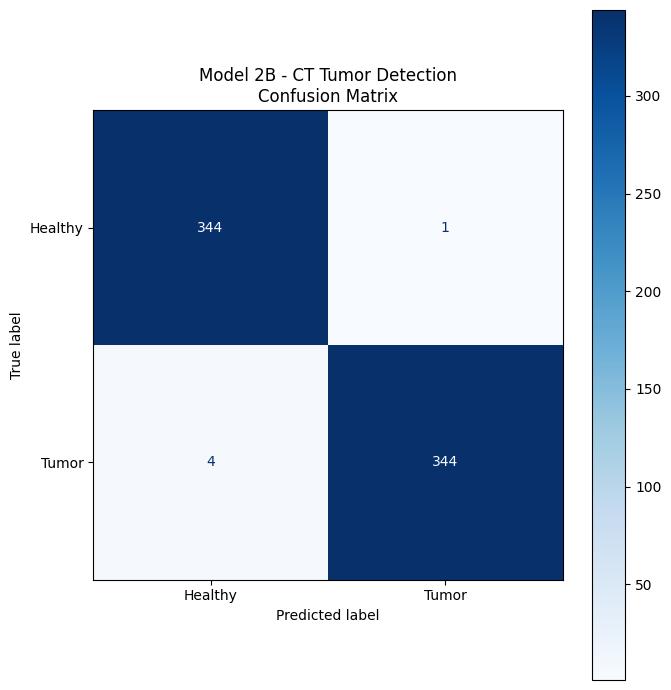


Confusion matrix:
[[344   1]
 [  4 344]]

Interpretation:
Healthy → Healthy : 344
Healthy → Tumor   : 1
Tumor → Healthy   : 4
Tumor → Tumor     : 344



In [28]:
# ============================================================
# MODEL 2B - CT TUMOR DETECTION
# STEP 23: CONFUSION MATRIX VISUALIZATION
# ============================================================

import matplotlib.pyplot as plt
from sklearn.metrics import ConfusionMatrixDisplay

print("=" * 70)
print("MODEL 2B - CONFUSION MATRIX")
print("=" * 70)

# Create visualization
disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=[
        "Healthy",
        "Tumor"
    ]
)

fig, ax = plt.subplots(
    figsize=(7, 7)
)

disp.plot(
    ax=ax,
    cmap="Blues",
    values_format="d"
)

ax.set_title(
    "Model 2B - CT Tumor Detection\nConfusion Matrix"
)

plt.tight_layout()
plt.show()

print("\nConfusion matrix:")
print(cm)

print("\nInterpretation:")
print(
    f"Healthy → Healthy : {cm[0,0]}"
)

print(
    f"Healthy → Tumor   : {cm[0,1]}"
)

print(
    f"Tumor → Healthy   : {cm[1,0]}"
)

print(
    f"Tumor → Tumor     : {cm[1,1]}"
)

print("\n" + "=" * 70)

MODEL 2B - INDIVIDUAL INTERNAL CT TEST

Image      : ct_healthy (648).jpg
Actual     : Healthy
Prediction : Healthy
Confidence : 99.94%
Result     : ✅ CORRECT


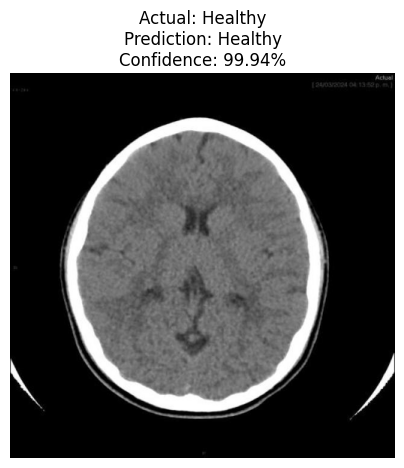


Image      : ct_healthy (564).jpg
Actual     : Healthy
Prediction : Healthy
Confidence : 99.26%
Result     : ✅ CORRECT


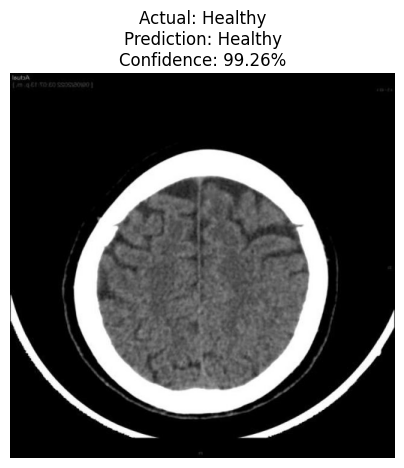


Image      : ct_healthy (133).jpg
Actual     : Healthy
Prediction : Healthy
Confidence : 99.73%
Result     : ✅ CORRECT


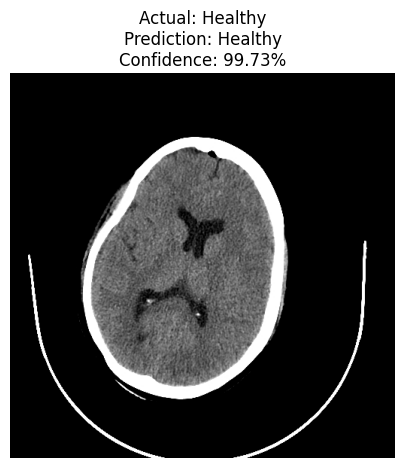


Image      : ct_healthy (378).jpg
Actual     : Healthy
Prediction : Healthy
Confidence : 100.00%
Result     : ✅ CORRECT


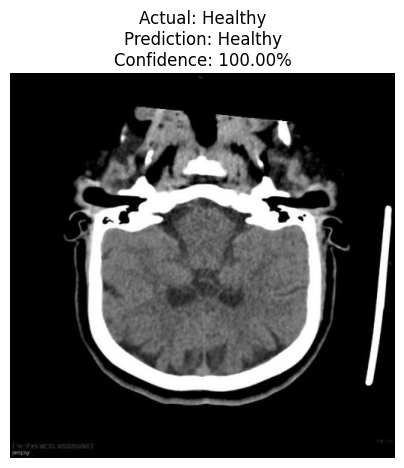


Image      : ct_tumor (2026).jpg
Actual     : Tumor
Prediction : Tumor
Confidence : 99.99%
Result     : ✅ CORRECT


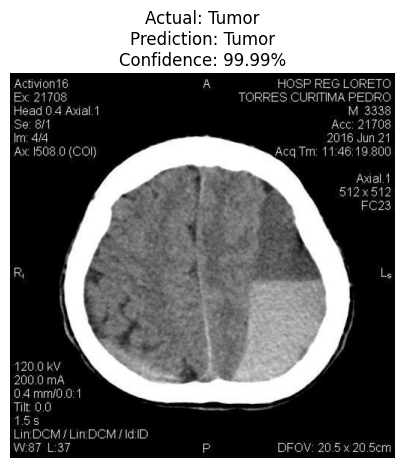


Image      : ct_healthy (1479).jpg
Actual     : Healthy
Prediction : Healthy
Confidence : 100.00%
Result     : ✅ CORRECT


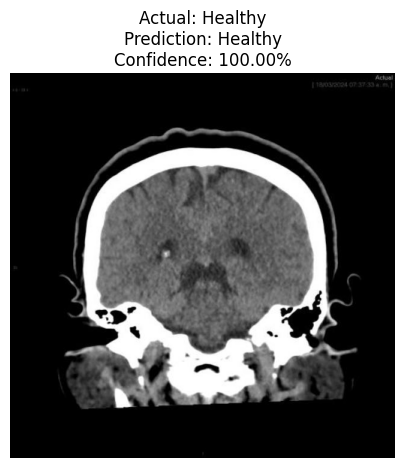


INDIVIDUAL CT TEST COMPLETE


In [29]:
# ============================================================
# MODEL 2B - CT TUMOR DETECTION
# STEP 24: INDIVIDUAL INTERNAL CT TEST
# ============================================================

import os
import random
import torch
import matplotlib.pyplot as plt
from PIL import Image


CLASS_NAMES = {
    0: "Healthy",
    1: "Tumor"
}


# ============================================================
# PREDICTION FUNCTION
# ============================================================

def predict_ct(image_path):

    # --------------------------------------------------------
    # Load image
    # --------------------------------------------------------

    image = Image.open(
        image_path
    ).convert("RGB")

    original_image = image.copy()

    # --------------------------------------------------------
    # Same preprocessing used for test data
    # --------------------------------------------------------

    image_tensor = test_ct_transform(
        image
    )

    image_tensor = image_tensor.unsqueeze(
        0
    ).to(device)

    # --------------------------------------------------------
    # Prediction
    # --------------------------------------------------------

    ct_model.eval()

    with torch.no_grad():

        outputs = ct_model(
            image_tensor
        )

        probabilities = torch.softmax(
            outputs,
            dim=1
        )

        confidence, prediction = torch.max(
            probabilities,
            dim=1
        )

    predicted_label = prediction.item()

    confidence_value = (
        confidence.item() * 100
    )

    return (
        original_image,
        predicted_label,
        confidence_value
    )


# ============================================================
# SELECT 6 RANDOM INTERNAL TEST IMAGES
# ============================================================

random.seed(42)

sample_count = min(
    6,
    len(test_ct_df)
)

sample_indices = random.sample(
    range(len(test_ct_df)),
    sample_count
)


print("=" * 70)
print("MODEL 2B - INDIVIDUAL INTERNAL CT TEST")
print("=" * 70)


# ============================================================
# TEST EACH IMAGE
# ============================================================

for index in sample_indices:

    row = test_ct_df.iloc[index]

    image_path = row["filepath"]

    actual_label = int(
        row["label"]
    )

    (
        image,
        predicted_label,
        confidence
    ) = predict_ct(
        image_path
    )

    actual_class = CLASS_NAMES[
        actual_label
    ]

    predicted_class = CLASS_NAMES[
        predicted_label
    ]

    print("\nImage      :", os.path.basename(
        image_path
    ))

    print(
        "Actual     :",
        actual_class
    )

    print(
        "Prediction :",
        predicted_class
    )

    print(
        f"Confidence : {confidence:.2f}%"
    )

    if actual_label == predicted_label:

        print(
            "Result     : ✅ CORRECT"
        )

    else:

        print(
            "Result     : ❌ INCORRECT"
        )


    # --------------------------------------------------------
    # Display image
    # --------------------------------------------------------

    plt.figure(
        figsize=(5, 5)
    )

    plt.imshow(
        image
    )

    plt.title(
        f"Actual: {actual_class}\n"
        f"Prediction: {predicted_class}\n"
        f"Confidence: {confidence:.2f}%"
    )

    plt.axis("off")

    plt.show()


print("\n" + "=" * 70)
print("INDIVIDUAL CT TEST COMPLETE")
print("=" * 70)

MODEL 2B - UPLOAD 4 EXTERNAL CT IMAGES

Please select 4 CT images.


Saving ct brain tumor.jpeg to ct brain tumor.jpeg
Saving CT brain.jpg to CT brain.jpg
Saving images.jpg to images.jpg
Saving MRI_of_Human_Brain.jpg to MRI_of_Human_Brain.jpg

Uploaded images:
 - ct brain tumor.jpeg
 - CT brain.jpg
 - images.jpg
 - MRI_of_Human_Brain.jpg


MODEL 2B - EXTERNAL CT PREDICTIONS

Image      : ct brain tumor.jpeg
Prediction : Tumor
Confidence : 99.86%


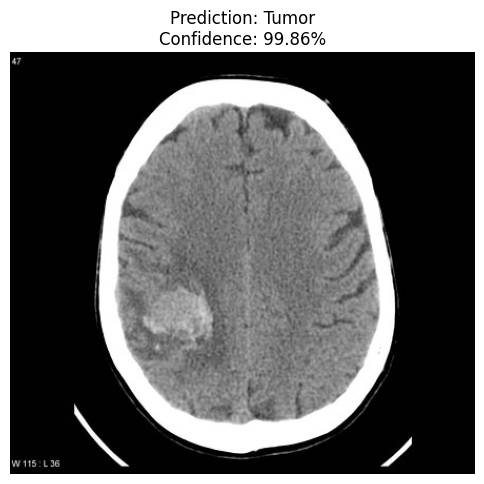


Image      : CT brain.jpg
Prediction : Healthy
Confidence : 98.75%


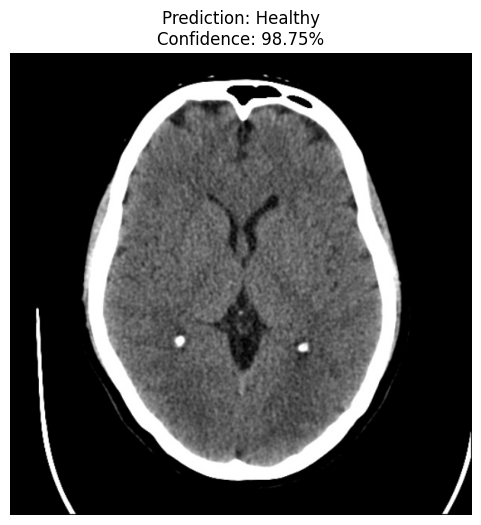


Image      : images.jpg
Prediction : Tumor
Confidence : 99.94%


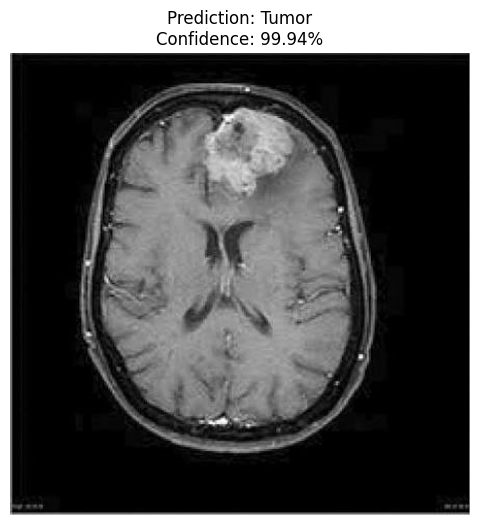


Image      : MRI_of_Human_Brain.jpg
Prediction : Healthy
Confidence : 73.45%


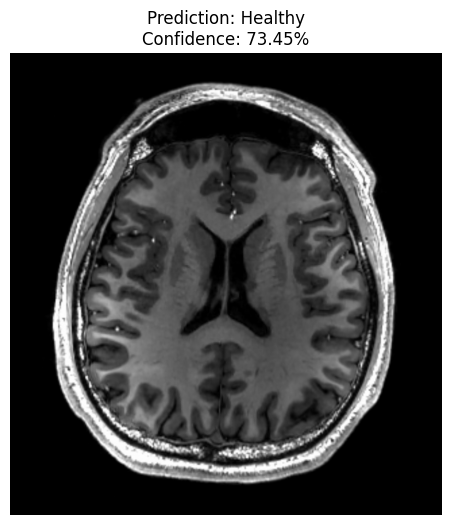



EXTERNAL CT TEST SUMMARY

ct brain tumor.jpeg
Prediction : Tumor
Confidence : 99.86%

CT brain.jpg
Prediction : Healthy
Confidence : 98.75%

images.jpg
Prediction : Tumor
Confidence : 99.94%

MRI_of_Human_Brain.jpg
Prediction : Healthy
Confidence : 73.45%

EXTERNAL TEST COMPLETE


In [30]:
# ============================================================
# MODEL 2B - CT TUMOR DETECTION
# STEP 25: EXTERNAL CT TEST - 4 INPUTS
# ============================================================

from google.colab import files
from PIL import Image
import torch
import matplotlib.pyplot as plt
import os


CLASS_NAMES = {
    0: "Healthy",
    1: "Tumor"
}


# ============================================================
# UPLOAD 4 EXTERNAL CT IMAGES
# ============================================================

print("=" * 70)
print("MODEL 2B - UPLOAD 4 EXTERNAL CT IMAGES")
print("=" * 70)

print("\nPlease select 4 CT images.")

uploaded = files.upload()

print("\nUploaded images:")
for filename in uploaded.keys():
    print(" -", filename)


# ============================================================
# PREDICTION FUNCTION
# ============================================================

def predict_external_ct(image_path):

    # Load image
    image = Image.open(
        image_path
    ).convert("RGB")

    original_image = image.copy()

    # Same preprocessing used during testing
    image_tensor = test_ct_transform(
        image
    )

    # Add batch dimension
    image_tensor = image_tensor.unsqueeze(
        0
    ).to(device)

    # Prediction
    ct_model.eval()

    with torch.no_grad():

        outputs = ct_model(
            image_tensor
        )

        probabilities = torch.softmax(
            outputs,
            dim=1
        )

        confidence, prediction = torch.max(
            probabilities,
            dim=1
        )

    predicted_label = prediction.item()

    confidence_value = (
        confidence.item() * 100
    )

    return (
        original_image,
        predicted_label,
        confidence_value
    )


# ============================================================
# TEST ALL 4 INPUTS
# ============================================================

print("\n")
print("=" * 70)
print("MODEL 2B - EXTERNAL CT PREDICTIONS")
print("=" * 70)


results = []


for filename in uploaded.keys():

    image_path = filename

    (
        image,
        predicted_label,
        confidence
    ) = predict_external_ct(
        image_path
    )

    predicted_class = CLASS_NAMES[
        predicted_label
    ]

    results.append({
        "image": filename,
        "prediction": predicted_class,
        "confidence": confidence
    })


    # --------------------------------------------------------
    # Print result
    # --------------------------------------------------------

    print("\nImage      :", filename)

    print(
        "Prediction :",
        predicted_class
    )

    print(
        f"Confidence : {confidence:.2f}%"
    )


    # --------------------------------------------------------
    # Display image
    # --------------------------------------------------------

    plt.figure(
        figsize=(6, 6)
    )

    plt.imshow(
        image
    )

    plt.title(
        f"Prediction: {predicted_class}\n"
        f"Confidence: {confidence:.2f}%"
    )

    plt.axis("off")

    plt.show()


# ============================================================
# SUMMARY
# ============================================================

print("\n")
print("=" * 70)
print("EXTERNAL CT TEST SUMMARY")
print("=" * 70)

for result in results:

    print(
        f"\n{result['image']}"
    )

    print(
        f"Prediction : {result['prediction']}"
    )

    print(
        f"Confidence : "
        f"{result['confidence']:.2f}%"
    )

print("\n" + "=" * 70)
print("EXTERNAL TEST COMPLETE")
print("=" * 70)

In [31]:
# ============================================================
# MODEL 2B - CT TUMOR DETECTION
# STEP 26: FINAL MODEL SAVE & VERIFICATION
# ============================================================

import os
import torch

SOURCE_MODEL = "/content/BrainTumor_CT_Detector_Best.pth"

FINAL_MODEL = "/content/BrainTumor_CT_Detector_Final.pth"


# ============================================================
# CHECK SOURCE MODEL
# ============================================================

print("=" * 70)
print("MODEL 2B - FINAL MODEL VERIFICATION")
print("=" * 70)

if not os.path.exists(SOURCE_MODEL):

    raise FileNotFoundError(
        f"Best model not found:\n{SOURCE_MODEL}"
    )

print("\n✅ Best checkpoint found")


# ============================================================
# LOAD CHECKPOINT
# ============================================================

checkpoint = torch.load(
    SOURCE_MODEL,
    map_location="cpu",
    weights_only=False
)


# ============================================================
# VERIFY REQUIRED INFORMATION
# ============================================================

required_keys = [
    "model_state_dict",
    "optimizer_state_dict",
    "scheduler_state_dict",
    "epoch",
    "val_accuracy",
    "val_loss",
    "class_names",
    "architecture",
    "input_size",
    "channels"
]

print("\nCheckpoint contents:")

for key in required_keys:

    if key in checkpoint:

        print(
            f"✅ {key}"
        )

    else:

        print(
            f"⚠️ Missing: {key}"
        )


# ============================================================
# CREATE CLEAN FINAL CHECKPOINT
# ============================================================

final_checkpoint = {

    "model_state_dict":
        checkpoint["model_state_dict"],

    "architecture":
        "EfficientNet-B0",

    "task":
        "CT Brain Tumor Detection",

    "class_names":
        {
            0: "Healthy",
            1: "Tumor"
        },

    "input_size":
        (224, 224),

    "input_channels":
        3,

    "normalization":
        {
            "mean": [
                0.485,
                0.456,
                0.406
            ],
            "std": [
                0.229,
                0.224,
                0.225
            ]
        },

    "best_epoch":
        checkpoint["epoch"],

    "best_validation_accuracy":
        checkpoint["val_accuracy"],

    "best_validation_loss":
        checkpoint["val_loss"]
}


# ============================================================
# SAVE FINAL MODEL
# ============================================================

torch.save(
    final_checkpoint,
    FINAL_MODEL
)


# ============================================================
# VERIFY SAVED FILE
# ============================================================

if os.path.exists(FINAL_MODEL):

    file_size_mb = (
        os.path.getsize(FINAL_MODEL)
        / (1024 * 1024)
    )

    print("\n" + "=" * 70)
    print("FINAL MODEL SAVED")
    print("=" * 70)

    print(
        "\nModel:",
        "BrainTumor_CT_Detector_Final.pth"
    )

    print(
        "Architecture:",
        "EfficientNet-B0"
    )

    print(
        "Task:",
        "CT Healthy/Tumor Detection"
    )

    print(
        "Classes:",
        "Healthy (0), Tumor (1)"
    )

    print(
        "Input:",
        "224 × 224 × 3 RGB"
    )

    print(
        "Best epoch:",
        checkpoint["epoch"]
    )

    print(
        "Best validation accuracy:",
        f"{checkpoint['val_accuracy']:.2f}%"
    )

    print(
        "File size:",
        f"{file_size_mb:.2f} MB"
    )

    print(
        "\nPath:",
        FINAL_MODEL
    )

    print("\n✅ FINAL MODEL VERIFIED")

else:

    print("❌ Final model was not saved")

print("=" * 70)

MODEL 2B - FINAL MODEL VERIFICATION

✅ Best checkpoint found

Checkpoint contents:
✅ model_state_dict
✅ optimizer_state_dict
✅ scheduler_state_dict
✅ epoch
✅ val_accuracy
✅ val_loss
✅ class_names
✅ architecture
✅ input_size
✅ channels

FINAL MODEL SAVED

Model: BrainTumor_CT_Detector_Final.pth
Architecture: EfficientNet-B0
Task: CT Healthy/Tumor Detection
Classes: Healthy (0), Tumor (1)
Input: 224 × 224 × 3 RGB
Best epoch: 9
Best validation accuracy: 99.28%
File size: 15.59 MB

Path: /content/BrainTumor_CT_Detector_Final.pth

✅ FINAL MODEL VERIFIED


In [32]:
# ============================================================
# MODEL 2B - STEP 27
# DOWNLOAD FINAL CT MODEL
# ============================================================

from google.colab import files
import os

FINAL_MODEL = "/content/BrainTumor_CT_Detector_Final.pth"

print("=" * 70)
print("MODEL 2B - DOWNLOAD FINAL MODEL")
print("=" * 70)

if not os.path.exists(FINAL_MODEL):
    raise FileNotFoundError(
        f"Model not found: {FINAL_MODEL}"
    )

file_size_mb = (
    os.path.getsize(FINAL_MODEL)
    / (1024 * 1024)
)

print("\nModel:")
print("BrainTumor_CT_Detector_Final.pth")

print("\nArchitecture:")
print("EfficientNet-B0")

print("\nTask:")
print("CT Healthy/Tumor Detection")

print("\nClass mapping:")
print("0 → Healthy")
print("1 → Tumor")

print("\nBest validation accuracy:")
print("99.28%")

print("\nFile size:")
print(f"{file_size_mb:.2f} MB")

print("\nDownloading...")

files.download(FINAL_MODEL)

print("\n✅ DOWNLOAD INITIATED")
print("=" * 70)

MODEL 2B - DOWNLOAD FINAL MODEL

Model:
BrainTumor_CT_Detector_Final.pth

Architecture:
EfficientNet-B0

Task:
CT Healthy/Tumor Detection

Class mapping:
0 → Healthy
1 → Tumor

Best validation accuracy:
99.28%

File size:
15.59 MB

Downloading...


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>


✅ DOWNLOAD INITIATED
